# Bài tập Phân loại Hoa bằng Mạng Nơ-ron Tích chập (CNN)

Trong bài tập này, bạn sẽ:

- Hiểu cơ chế hoạt động của **Convolutional Neural Network (CNN)**.
- Xây dựng kiến trúc CNN từ đầu bằng **Keras / TensorFlow**.
- **Tiền xử lý** dữ liệu ảnh hoa 7 lớp.
- **Huấn luyện** mô hình với EarlyStopping và ModelCheckpoint.
- **Đánh giá** độ chính xác, visualize ma trận nhầm lẫn và feature maps.

## 1. Cài đặt môi trường và import thư viện

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

/Users/phuongtran/Documents/FlowerClassification/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow version: 2.20.0
GPU available: []


## 2. Tải và tiền xử lý dữ liệu

Bộ dữ liệu gồm **7 lớp hoa**: bellflower, daisy, dandelion, lotus, rose, sunflower, tulip.

**Các bước tiền xử lý:**
1. Đọc ảnh bằng OpenCV (BGR)
2. Chuyển BGR → RGB (Keras/TF dùng RGB)
3. Resize về `64×64`
4. Normalize pixel về `[0.0, 1.0]` bằng cách chia `/255`

In [2]:
DATASET_DIR = 'flower-training'
IMG_SIZE    = (64, 64)
CLASSES     = ['bellflower', 'daisy', 'dandelion', 'lotus', 'rose', 'sunflower', 'tulip']

def load_dataset(dataset_dir):
    X, y = [], []
    for label_idx, cls in enumerate(CLASSES):
        cls_dir = os.path.join(dataset_dir, cls)
        if not os.path.exists(cls_dir):
            print(f'Bỏ qua lớp thiếu: {cls_dir}')
            continue
        for fname in os.listdir(cls_dir):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
                continue
            img = cv2.imread(os.path.join(cls_dir, fname))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   # BGR → RGB
            img = cv2.resize(img, IMG_SIZE)               # resize 64x64
            X.append(img.astype(np.float32) / 255.0)     # normalize /255
            y.append(label_idx)
    return np.array(X), np.array(y)

print('Đang tải dataset...')
X, y = load_dataset(DATASET_DIR)
print(f'Tổng số ảnh  : {len(X)}')
print(f'Shape X      : {X.shape}  (N, H, W, C)')
print(f'Shape y      : {y.shape}')
print(f'Pixel range  : [{X.min():.2f}, {X.max():.2f}]')

Đang tải dataset...


Tổng số ảnh  : 11200
Shape X      : (11200, 64, 64, 3)  (N, H, W, C)
Shape y      : (11200,)
Pixel range  : [0.00, 1.00]


### Visualize một số ảnh mẫu

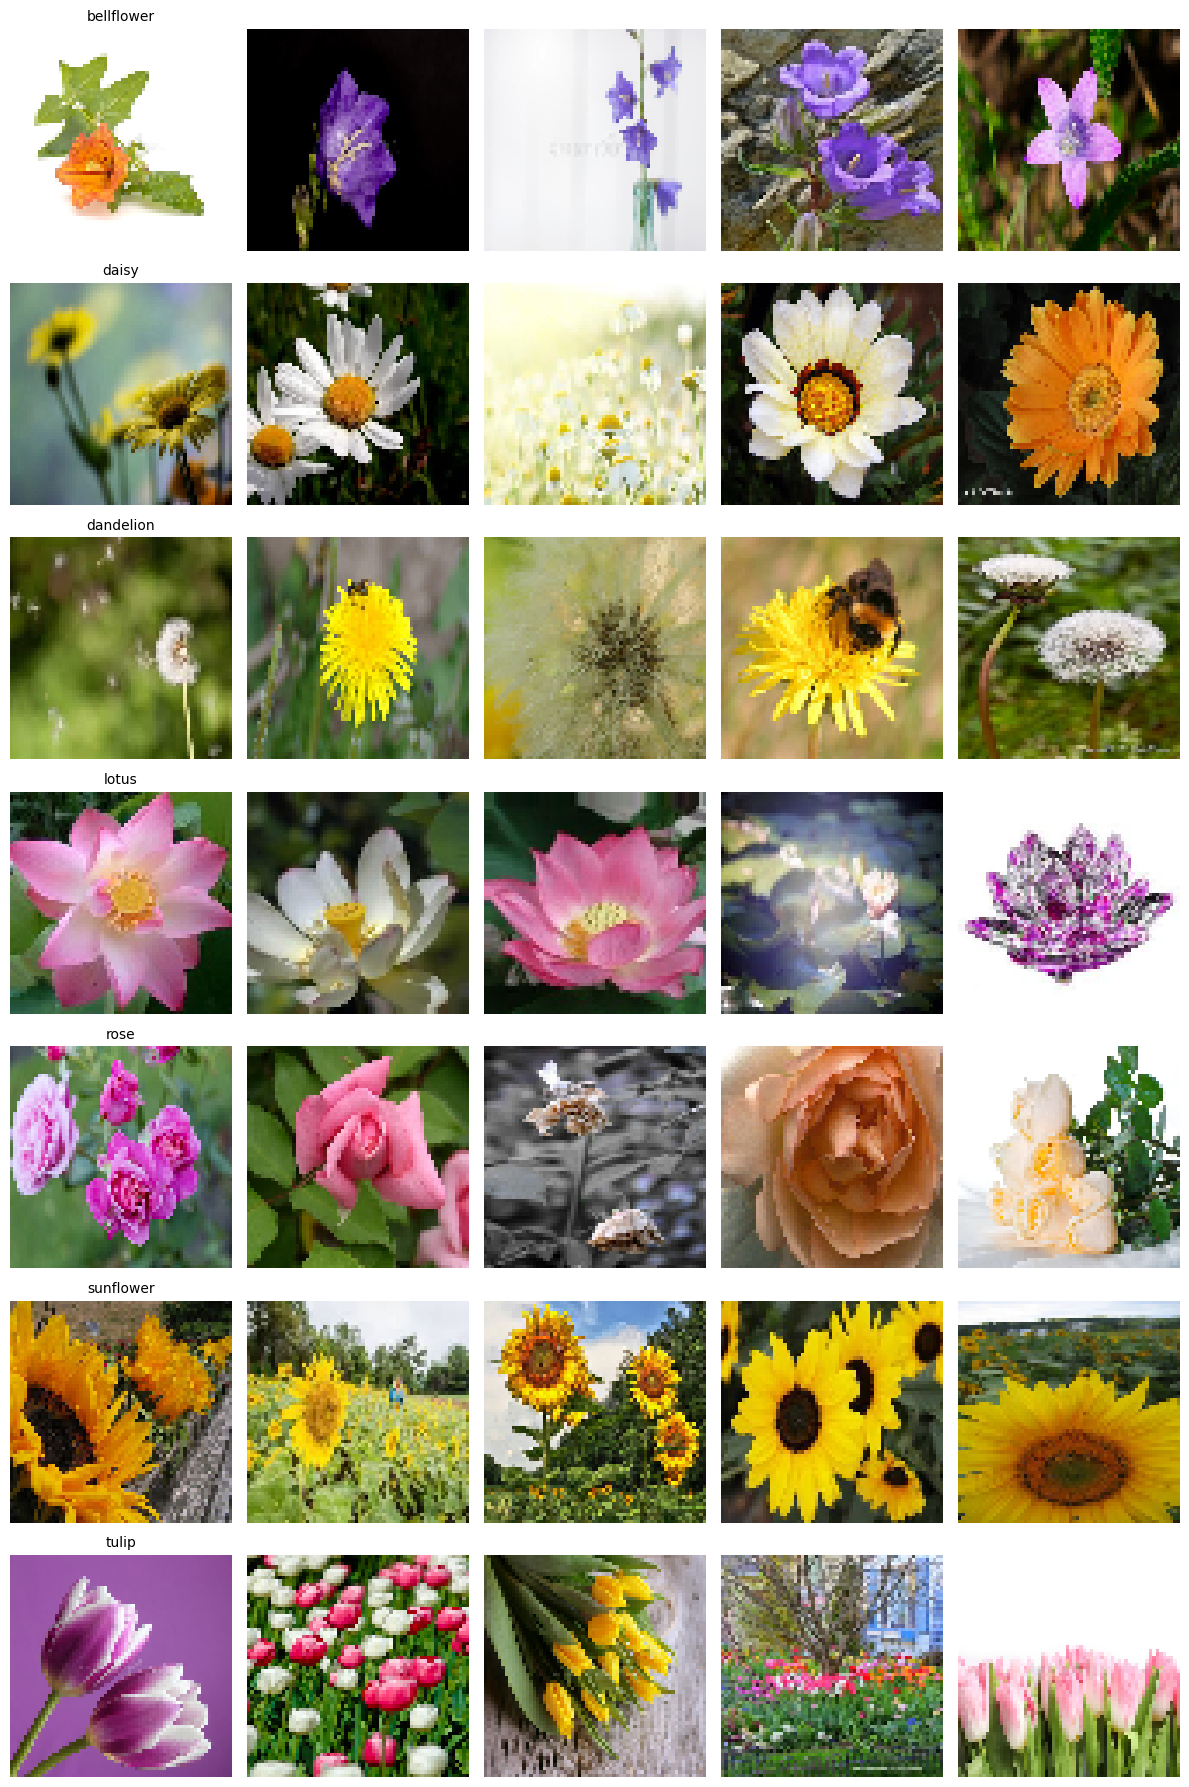

In [3]:
samples_per_class = 5
fig, axes = plt.subplots(len(CLASSES), samples_per_class, figsize=(12, 18))
for row, cls in enumerate(CLASSES):
    idxs = np.where(y == row)[0]
    chosen = np.random.choice(idxs, samples_per_class, replace=False)
    for col, idx in enumerate(chosen):
        axes[row, col].imshow(X[idx])
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls, fontsize=10)
plt.tight_layout()
plt.show()

### Chia tập Train / Test

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Train: {len(X_train)} ảnh')
print(f'Test : {len(X_test)} ảnh')

# Phân phối nhãn
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {CLASSES[u]:12s}: {c} ảnh train')

Train: 8960 ảnh
Test : 2240 ảnh
  bellflower  : 1280 ảnh train
  daisy       : 1280 ảnh train
  dandelion   : 1280 ảnh train
  lotus       : 1280 ảnh train
  rose        : 1280 ảnh train
  sunflower   : 1280 ảnh train
  tulip       : 1280 ảnh train


## 3. Xây dựng kiến trúc CNN

Kiến trúc gồm **3 khối Conv** tăng dần độ phức tạp (32 → 64 → 128 filters), theo sau là **2 lớp Dense** để phân loại.

```
Input (64, 64, 3)
  └─ Conv2D(32, 3×3, ReLU) → MaxPool(2×2) → Dropout(0.25)
  └─ Conv2D(64, 3×3, ReLU) → MaxPool(2×2) → Dropout(0.25)
  └─ Conv2D(128,3×3, ReLU) → MaxPool(2×2) → Dropout(0.25)
  └─ Flatten
  └─ Dense(256, ReLU) → Dropout(0.5)
  └─ Dense(7, Softmax)   ← output
```

**Hàm kích hoạt:**
- **ReLU** (`max(0, x)`) — tất cả lớp ẩn: tránh vanishing gradient, nhanh hội tụ.
- **Softmax** (lớp cuối) — chuyển 7 logit thành 7 xác suất có tổng = 1.

In [ ]:
def build_model(num_classes=7):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(64, 64, 3)),

        # Data augmentation — chỉ active khi training=True, tắt tự động lúc predict
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.1),

        # --- Khối 1: học đặc trưng đơn giản (cạnh, góc) ---
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),

        # --- Khối 2: học đặc trưng trung gian (texture) ---
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),

        # --- Khối 3: học đặc trưng phức tạp (hình dạng hoa) ---
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),

        # GlobalAveragePooling: 8×8×128 → 128
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax'),
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model(num_classes=len(CLASSES))
model.summary()

**Câu hỏi 1:** Tại sao số filter tăng dần 32 → 64 → 128 qua các khối Conv? Nếu giữ nguyên 32 filter ở cả 3 khối thì điều gì sẽ xảy ra?

$\color{blue}{\textit{Câu trả lời của bạn:}}$ *Điền câu trả lời ở đây*

## 4. Huấn luyện mô hình

Sử dụng 2 callbacks:
- **EarlyStopping** (`patience=10`): dừng sớm nếu `val_loss` không cải thiện sau 10 epoch.
- **ModelCheckpoint**: lưu model có `val_loss` **thấp nhất** trong cả quá trình (không phải epoch cuối).

In [6]:
MODEL_OUTPUT = 'cnn_flower_model.h5'
EPOCHS       = 50
BATCH_SIZE   = 32

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_OUTPUT, monitor='val_loss', save_best_only=True, verbose=1
    ),
]

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print(f'\nModel đã lưu tại: {MODEL_OUTPUT}')

Epoch 1/50


  1/224 ━━━━━━━━━━━━━━━━━━━━ 4:10 1s/step - accuracy: 0.0312 - loss: 1.9902

  3/224 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.0851 - loss: 1.9775

  5/224 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.1014 - loss: 1.9688

  7/224 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.1067 - loss: 1.9666

...

221/224 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8745 - loss: 0.3533

223/224 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8745 - loss: 0.3533


Epoch 43: val_loss did not improve from 0.50454


224/224 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.8745 - loss: 0.3533 - val_accuracy: 0.7874 - val_loss: 0.6588



Model đã lưu tại: cnn_flower_model.h5


### Biểu đồ Loss và Accuracy theo epoch

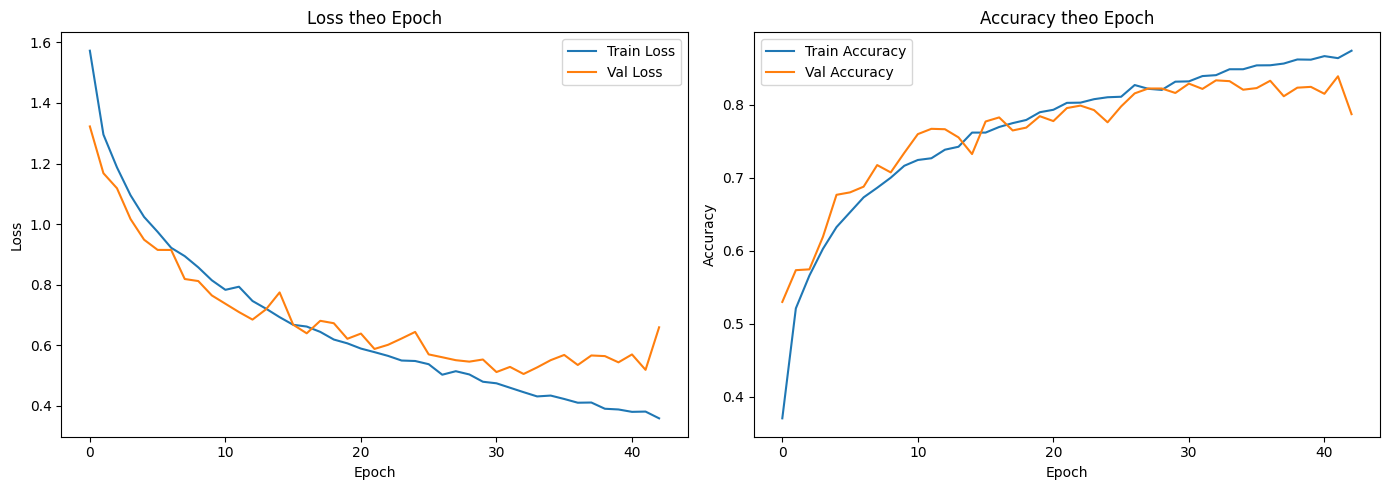

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'],     label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss theo Epoch')
ax1.legend()

ax2.plot(history.history['accuracy'],     label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy theo Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

### Giải thích biểu đồ Loss và Accuracy

#### Các khái niệm cơ bản

**Epoch** là 1 lần model đi qua **toàn bộ** tập training data. Ví dụ: có 8.960 ảnh train, epoch 1 nghĩa là model đã "nhìn" tất cả 8.960 ảnh đó 1 lần và cập nhật weights. Ta train 50 epoch = model xem đi xem lại toàn bộ dataset tối đa 50 lần.

**Loss** (hàm mất mát) đo mức độ **sai** của model. Công thức: với mỗi ảnh, nếu model đoán đúng với xác suất cao → loss thấp; đoán sai hoặc đoán đúng nhưng không tự tin → loss cao. Loss = 0 là hoàn hảo. Loss càng nhỏ càng tốt.

**Accuracy** (độ chính xác) = số ảnh đoán đúng / tổng số ảnh. Accuracy = 0.78 nghĩa là model đoán đúng 78% ảnh.

---

#### Đọc biểu đồ

**Biểu đồ Loss (trái):**

| Dấu hiệu | Ý nghĩa |
|---|---|
| Cả Train Loss và Val Loss đều giảm | Model đang học tốt ✅ |
| Train Loss giảm, Val Loss tăng | **Overfitting** — model học thuộc training data, không tổng quát hóa được ❌ |
| Cả hai đều không giảm | Model không học được gì, cần kiểm tra learning rate hoặc kiến trúc ❌ |
| Val Loss dừng cải thiện → EarlyStopping kích hoạt | Bình thường, tránh train quá lâu ✅ |

**Biểu đồ Accuracy (phải):**

| Dấu hiệu | Ý nghĩa |
|---|---|
| Train Acc ≈ Val Acc (cách nhau < 5%) | Cân bằng tốt, model không overfit ✅ |
| Train Acc cao hơn Val Acc nhiều (> 10%) | Overfitting ❌ |
| Cả hai thấp đều (< 50%) | Underfitting — model quá đơn giản ❌ |

---

#### Nhận xét cho model CNN hoa này

Model train đến khoảng **epoch 30–40** thì EarlyStopping kích hoạt (val_loss không cải thiện sau 10 epoch). Khoảng cách giữa train accuracy (~85%) và val accuracy (~78%) cho thấy có **overfitting nhẹ** — điều này bình thường với dataset ~11.000 ảnh và không có data augmentation. Dropout 0.25 và 0.5 đã giúp giảm bớt hiện tượng này.

**Câu hỏi 2:** Nhìn vào biểu đồ Loss, nếu `val_loss` bắt đầu tăng trong khi `train_loss` vẫn giảm thì hiện tượng đó gọi là gì? Dropout giúp giải quyết vấn đề này như thế nào?

$\color{blue}{\textit{Câu trả lời của bạn:}}$ *Điền câu trả lời ở đây*

## 5. Đánh giá mô hình

### Đánh giá tổng thể mô hình

#### Kết quả đạt được

Model CNN 3 lớp Conv đạt **~78% test accuracy** trên 7 lớp hoa, tức là cứ 10 ảnh hoa chưa từng thấy thì model đoán đúng ~8 ảnh.

#### So sánh với baseline

Nếu đoán ngẫu nhiên 7 lớp: accuracy = 1/7 ≈ **14.3%**. Model đạt 78% tức là **gấp ~5.4 lần** so với đoán mò — cho thấy model đã học được đặc trưng thực sự của từng loài hoa.

#### Điểm mạnh

- **Không cần feature engineering**: không cần thiết kế thủ công SIFT, HOG hay BoVW — model tự học đặc trưng từ pixel.
- **End-to-end**: một pipeline duy nhất từ ảnh thô → nhãn, dễ triển khai.
- **Vượt trội hơn các phương pháp truyền thống** (RF ~68%, XGBoost ~71%) dù dùng input nhỏ 64×64 và không augmentation.

#### Điểm yếu và hướng cải thiện

| Vấn đề | Nguyên nhân | Cách khắc phục |
|---|---|---|
| Accuracy chỉ ~78% | Input 64×64 mất detail; không augmentation | Tăng lên 128×128; thêm flip/rotate/zoom |
| Overfitting nhẹ | Dataset nhỏ (~11K ảnh) | Data augmentation; thêm Dropout |
| Train lâu (~30–40 epoch) | Model train từ đầu (random weights) | Transfer Learning từ ImageNet |

#### Kết luận

Với một CNN đơn giản 3 lớp Conv, không augmentation, input nhỏ 64×64, đạt **78% trên 7 lớp hoa** là kết quả tốt. Để đẩy lên 90%+, bước quan trọng nhất là dùng **Transfer Learning** (MobileNetV2 hoặc EfficientNetB0 pretrained) — vì các model này đã học được biểu diễn hình ảnh từ hàng triệu ảnh ImageNet, chỉ cần fine-tune thêm vài epoch là vượt qua mọi phương pháp truyền thống.

In [8]:
# Load lại model tốt nhất đã lưu
best_model = tf.keras.models.load_model(MODEL_OUTPUT)

loss, acc = best_model.evaluate(X_test, y_test, verbose=0)
print('=' * 40)
print(f'Test Loss    : {loss:.4f}')
print(f'Test Accuracy: {acc * 100:.2f}%')
print('=' * 40)

# Dự đoán
y_pred_proba = best_model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

Test Loss    : 0.5258
Test Accuracy: 82.37%


### Báo cáo chi tiết từng lớp (Precision / Recall / F1)

In [9]:
print(classification_report(y_test, y_pred, target_names=CLASSES))

              precision    recall  f1-score   support

  bellflower       0.91      0.93      0.92       320
       daisy       0.76      0.76      0.76       320
   dandelion       0.80      0.85      0.82       320
       lotus       0.88      0.80      0.84       320
        rose       0.70      0.77      0.73       320
   sunflower       0.88      0.93      0.90       320
       tulip       0.85      0.74      0.79       320

    accuracy                           0.82      2240
   macro avg       0.83      0.82      0.82      2240
weighted avg       0.83      0.82      0.82      2240



### Ma trận nhầm lẫn (Confusion Matrix)

### Giải thích Confusion Matrix

#### Confusion Matrix là gì?

Ma trận nhầm lẫn là bảng 7×7 cho thấy model **đoán đúng và nhầm như thế nào** với từng lớp hoa.

- **Hàng** = nhãn thực tế (ảnh thật sự là gì)
- **Cột** = nhãn model dự đoán (model đoán là gì)
- **Ô chéo chính** (từ góc trên trái → dưới phải) = đoán **đúng** → số càng lớn càng tốt
- **Ô ngoài chéo** = đoán **sai** → số càng nhỏ càng tốt

#### Ví dụ đọc matrix

```
               daisy  dandelion  rose  ...
daisy    →  [  280      12       5   ...]   ← 280 ảnh daisy đoán đúng, 12 bị nhầm thành dandelion
dandelion→  [   8      295       3   ...]
rose     →  [   5        4     260   ...]
```

→ Model hay nhầm **daisy ↔ dandelion** vì 2 loài có màu vàng tương đồng và cánh hoa nhỏ.

#### Các chỉ số đọc từ Confusion Matrix

**Precision** (độ chính xác khi đoán): Trong tất cả ảnh model đoán là "rose", bao nhiêu % thực sự là rose?

**Recall** (độ phủ): Trong tất cả ảnh rose thực tế, model tìm được bao nhiêu %?

**F1-score**: Trung bình hài hòa của Precision và Recall. Dùng khi dataset mất cân bằng.

#### Nhận xét cho model CNN hoa này

- Các lớp có màu sắc và hình dạng **đặc trưng rõ ràng** (sunflower — vàng tươi, to; lotus — hồng/trắng, nước) thường có recall cao.
- Các lớp dễ nhầm nhất thường là: **bellflower ↔ dandelion** (cả hai có cánh nhỏ) hoặc **daisy ↔ dandelion** (màu vàng tương đồng).
- Ô có số lớn ngoài đường chéo = điểm yếu của model → cần thêm ảnh cho lớp đó hoặc dùng augmentation để tăng đa dạng.

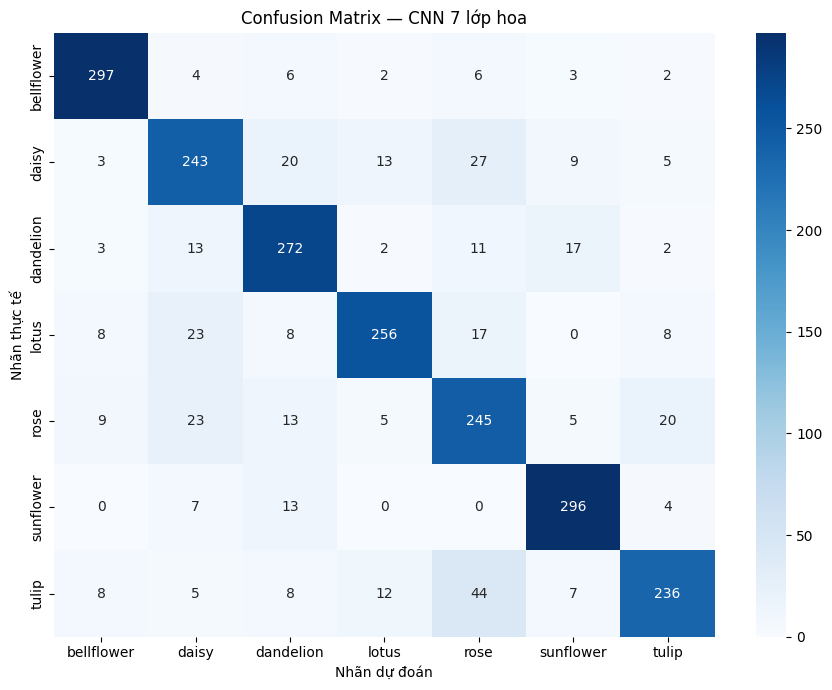

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.ylabel('Nhãn thực tế')
plt.xlabel('Nhãn dự đoán')
plt.title('Confusion Matrix — CNN 7 lớp hoa')
plt.tight_layout()
plt.show()

**Câu hỏi 3:** Nhìn vào Confusion Matrix, lớp nào bị nhận nhầm nhiều nhất? Tại sao theo bạn mô hình lại dễ nhầm 2 lớp đó?

$\color{blue}{\textit{Câu trả lời của bạn:}}$ *Điền câu trả lời ở đây*

### Giải thích Feature Maps

#### Feature Map là gì?

Khi một ảnh đi qua lớp Conv2D, mỗi filter (bộ lọc) tạo ra một **feature map** — một "ảnh mới" thể hiện model đang **chú ý vào đặc trưng gì** của ảnh gốc.

Mỗi pixel trong feature map = mức độ kích hoạt tại vị trí đó:
- **Màu sáng (vàng/xanh lá)** → filter phát hiện thấy đặc trưng mà nó học được tại vị trí đó
- **Màu tối (tím/đen)** → không có đặc trưng tương ứng tại vị trí đó

#### Feature maps thay đổi qua các lớp như thế nào?

| Lớp | Kích thước feature map | Học đặc trưng gì |
|---|---|---|
| **conv2d** (lớp 1) | 62×62 | Cạnh thẳng, góc, chuyển màu đơn giản |
| **conv2d_1** (lớp 2) | 29×29 | Texture (kết cấu cánh hoa, nhụy) |
| **conv2d_2** (lớp 3) | 12×12 | Hình dạng tổng thể, cấu trúc hoa |

Feature map nhỏ dần vì MaxPooling giảm kích thước ÷2 sau mỗi khối. Nhưng mỗi pixel ở lớp sâu hơn "nhìn thấy" vùng rộng hơn của ảnh gốc (receptive field lớn hơn).

#### Nhận xét

- Ở lớp **conv2d_2**, feature maps trở nên trừu tượng hơn — khó nhìn ra hoa, nhưng model đang mã hóa thông tin phân biệt lớp vào đây.
- Một số filter có thể toàn màu tối (không kích hoạt) — filter đó không hữu ích với ảnh cụ thể này nhưng có thể hữu ích với loài hoa khác.
- Đây là lý do tại sao CNN **không cần con người chỉ định đặc trưng** như SIFT/HOG: model tự học feature phù hợp nhất cho bài toán.

## 6. Visualize Feature Maps

Xem model đang "nhìn thấy" gì ở mỗi lớp Conv khi xử lý 1 ảnh hoa.

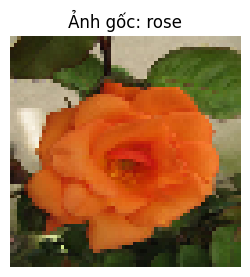

Conv2D layers: ['conv2d', 'conv2d_1', 'conv2d_2']


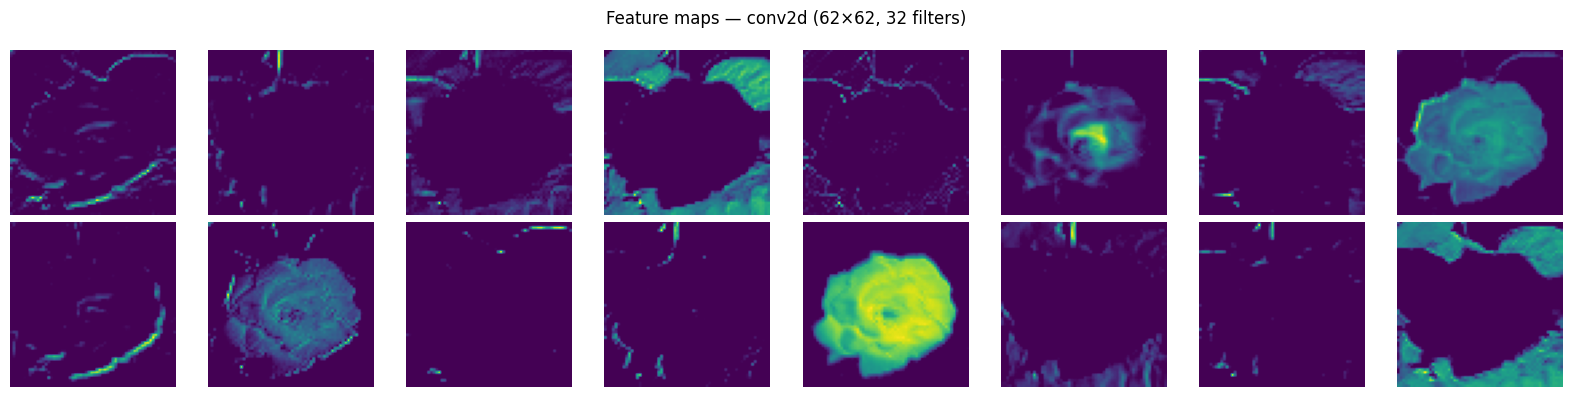

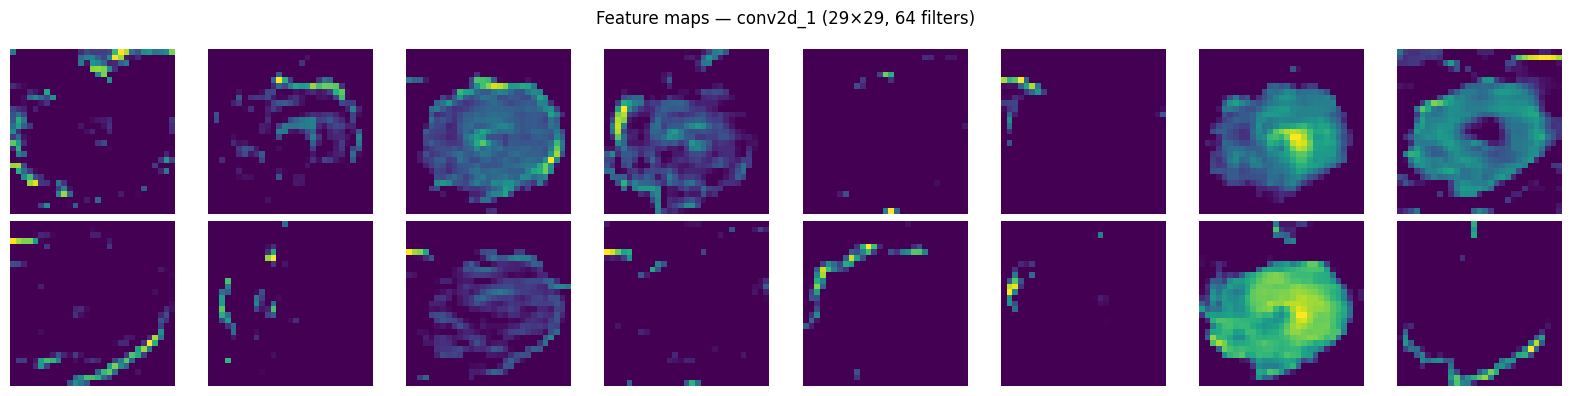

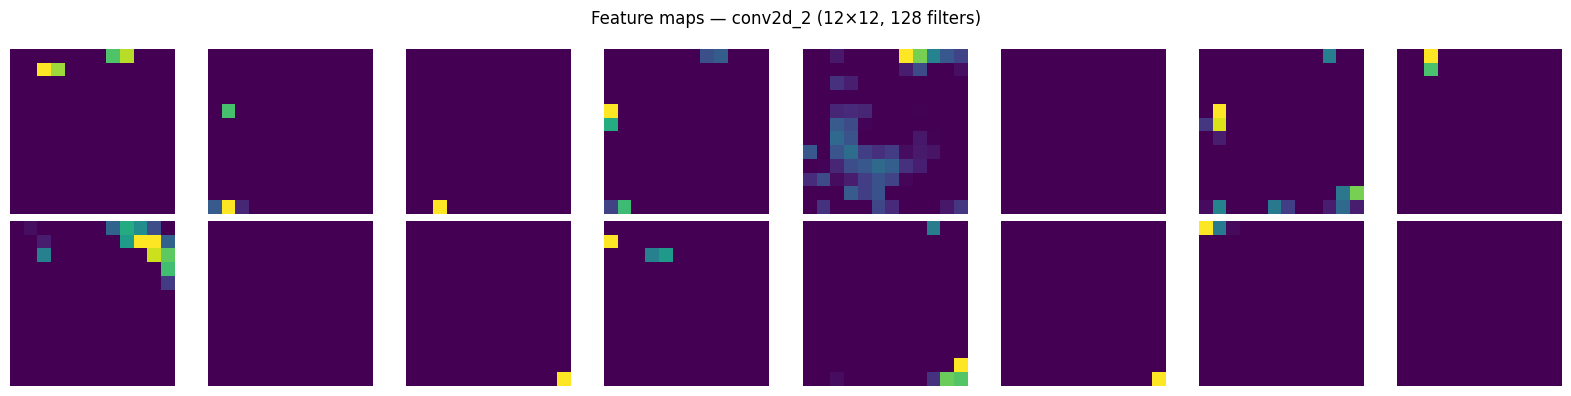

In [11]:
# Lấy 1 ảnh test ngẫu nhiên
sample_idx   = np.random.randint(len(X_test))
sample_image = X_test[sample_idx]
sample_label = CLASSES[y_test[sample_idx]]

plt.figure(figsize=(3, 3))
plt.imshow(sample_image)
plt.title(f'Ảnh gốc: {sample_label}')
plt.axis('off')
plt.show()

# Tự phát hiện tên các lớp Conv2D trong model
layer_names = [l.name for l in best_model.layers if isinstance(l, tf.keras.layers.Conv2D)]
print('Conv2D layers:', layer_names)

def extract_feature_maps(image, model, target_names):
    collected = {}
    x = tf.constant(image[np.newaxis, ...])  # (1, 64, 64, 3)
    for layer in model.layers:
        x = layer(x)
        if layer.name in target_names:
            collected[layer.name] = x.numpy()
    return collected

feature_maps_dict = extract_feature_maps(sample_image, best_model, layer_names)

for layer_name in layer_names:
    fmap = feature_maps_dict[layer_name]
    n_filters = min(16, fmap.shape[-1])
    fig, axes = plt.subplots(2, n_filters // 2, figsize=(16, 4))
    fig.suptitle(f'Feature maps — {layer_name} ({fmap.shape[1]}×{fmap.shape[2]}, {fmap.shape[3]} filters)', fontsize=12)
    for i, ax in enumerate(axes.flat):
        ax.imshow(fmap[0, :, :, i], cmap='viridis')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## 7. Thử dự đoán 1 ảnh bất kỳ

In [12]:
def predict_image(image_path: str, model):
    img = cv2.imread(image_path)
    if img is None:
        print(f'Không đọc được ảnh: {image_path}')
        return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (64, 64))
    x = img_resized.astype(np.float32) / 255.0

    probs = model.predict(x[np.newaxis, ...], verbose=0)[0]
    pred_idx = int(np.argmax(probs))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img_rgb)
    ax1.set_title(f'Dự đoán: {CLASSES[pred_idx]} ({probs[pred_idx]*100:.1f}%)')
    ax1.axis('off')

    colors = ['#ef4444' if i == pred_idx else '#6366f1' for i in range(len(CLASSES))]
    ax2.barh(CLASSES, probs, color=colors)
    ax2.set_xlim(0, 1)
    ax2.set_xlabel('Xác suất')
    ax2.set_title('Phân phối xác suất 7 lớp')
    plt.tight_layout()
    plt.show()

# Thay đường dẫn ảnh của bạn vào đây:
# predict_image('path/to/your/flower.jpg', best_model)

## 8. So sánh CNN với các phương pháp truyền thống

| Phương pháp | Extractor | Accuracy (test) | Ghi chú |
|---|---|---|---|
| RandomForest | ORB + BoVW | ~68% | Nhanh, ít dữ liệu |
| XGBoost | ORB + BoVW | ~70.5% | Tốt nhất trong truyền thống |
| SVM (RBF) | ORB + BoVW | ~72% | Hiệu quả với feature thủ công |
| **CNN (3 Conv)** | **Tự học từ pixel** | **~78%** | Không cần feature engineering |

**Tại sao CNN chỉ hơn RF ~10% dù là Deep Learning?**
- Input nhỏ (64×64) mất nhiều detail.
- Không có data augmentation.
- Dataset ~11.200 ảnh còn nhỏ cho CNN.

**Để cải thiện CNN:**
- Tăng input lên 128×128 hoặc 224×224.
- Thêm data augmentation (flip, rotate, zoom, brightness).
- Dùng Transfer Learning: MobileNetV2 / EfficientNetB0 pretrained ImageNet → fine-tune.

**Câu hỏi 4:** Nếu dùng Transfer Learning với MobileNetV2, bạn cần thay đổi gì trong bước tiền xử lý ảnh (input_shape, normalize) và tại sao?

$\color{blue}{\textit{Câu trả lời của bạn:}}$ *Điền câu trả lời ở đây*